In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install astropy
%pip install scipy
%pip install scikit-learn
%pip install gudhi

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg
import astropy
import math

In [3]:
data = pd.read_csv('M101.csv')
data.head()

mag_data = data['inst_vega_mag2'].values
diff_data = data['inst_vega_mag1'].values - mag_data
y_data = data['inst_vega_mag1'].values
x_data = -1 * diff_data

## Task 1: GLOESS Smoothed Luminosity Function

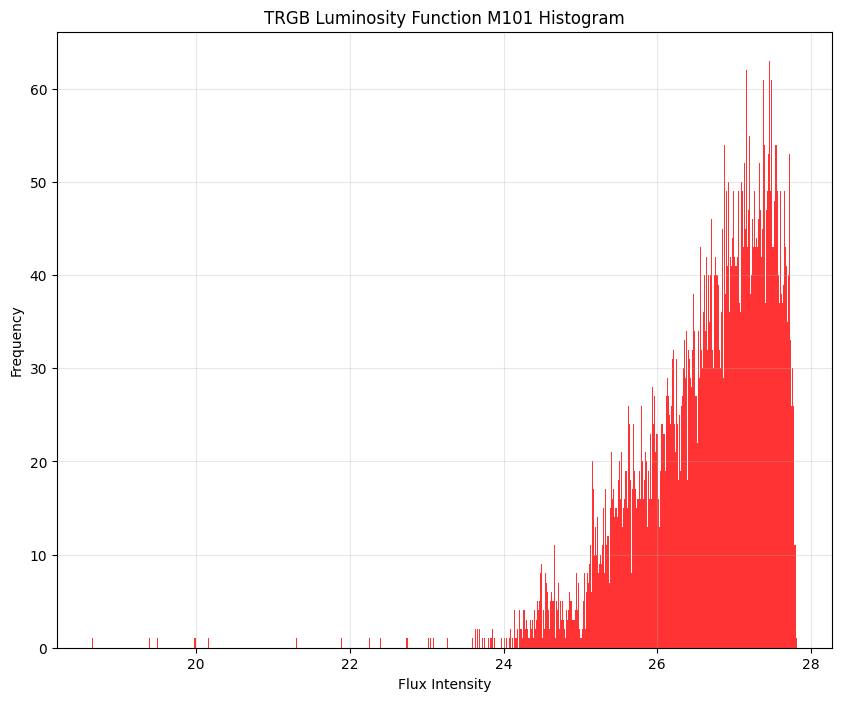

In [4]:
fig_hist, ax_hist = plt.subplots(figsize=(10, 8))

ax_hist.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='red', alpha=0.8)
ax_hist.set_xlabel('Flux Intensity')
ax_hist.set_ylabel('Frequency')
ax_hist.grid(True, alpha=0.3)
ax_hist.set_title('TRGB Luminosity Function M101 Histogram')

fig_hist.savefig('TRGB Luminosity Function M101 Histogram')

In [5]:
def gloess(mag, tau, bin_width = 0.01):
    fig_gloess, ax_gloess = plt.subplots(figsize = (10, 10))
    hist, bins, cont = ax_gloess.hist(mag, bins = np.arange(min(mag), max(mag) + bin_width, bin_width), color = 'black')
    plt.close()
    bin_centers = []
    for j in range(len(bins) - 1):
        bin_centers.append((bins[j] + bins[j + 1]) / 2)
    yest = np.zeros(len(hist))
    w = np.array([np.exp(- (bin_centers - bin_centers[i])**2/(2 * tau**2)) for i in range(len(hist))])
    for i in range(len(hist)):
        weights = w[i, :]
        b = np.array([np.sum(weights * hist), np.sum(weights * hist * bin_centers)])
        A = np.array([[np.sum(weights), np.sum(weights * bin_centers)],
                    [np.sum(weights * bin_centers), np.sum(weights * bin_centers * bin_centers)]])
        theta = linalg.solve(A, b)
        yest[i] = theta[0] + theta[1] * bin_centers[i]
    return yest, np.array(bin_centers)

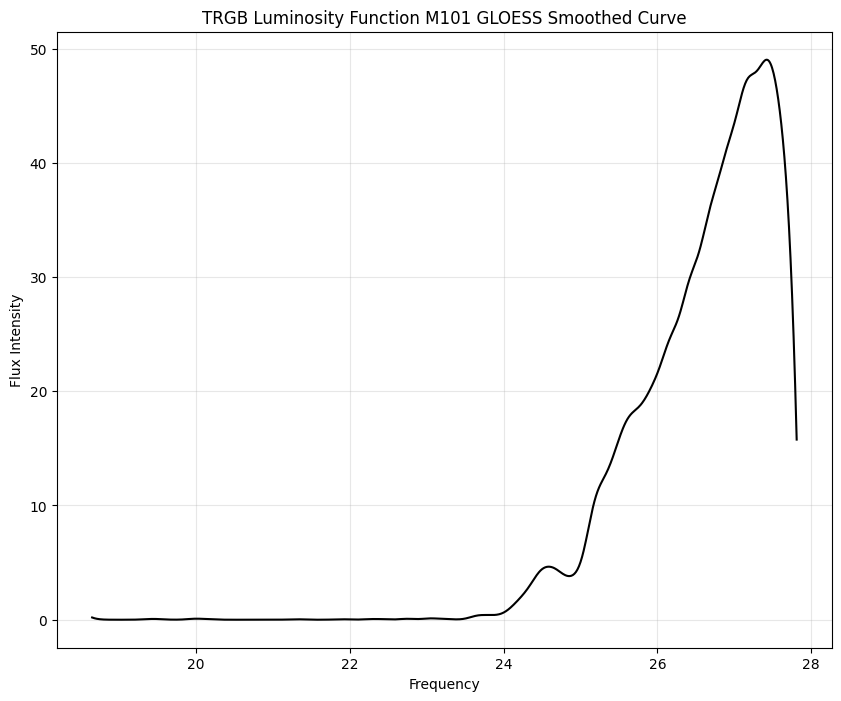

In [6]:
fig_sm, ax_sm = plt.subplots(figsize=(10, 8))

Y, X = gloess(mag_data, 0.10)
ax_sm.plot(X, Y, color='black')
ax_sm.set_ylabel('Flux Intensity')
ax_sm.set_xlabel('Frequency')
ax_sm.grid(True, alpha=0.3)
ax_sm.set_title('TRGB Luminosity Function M101 GLOESS Smoothed Curve')

fig_sm.savefig('TRGB Luminosity Function M101 GLOESS Smoothed Curve')

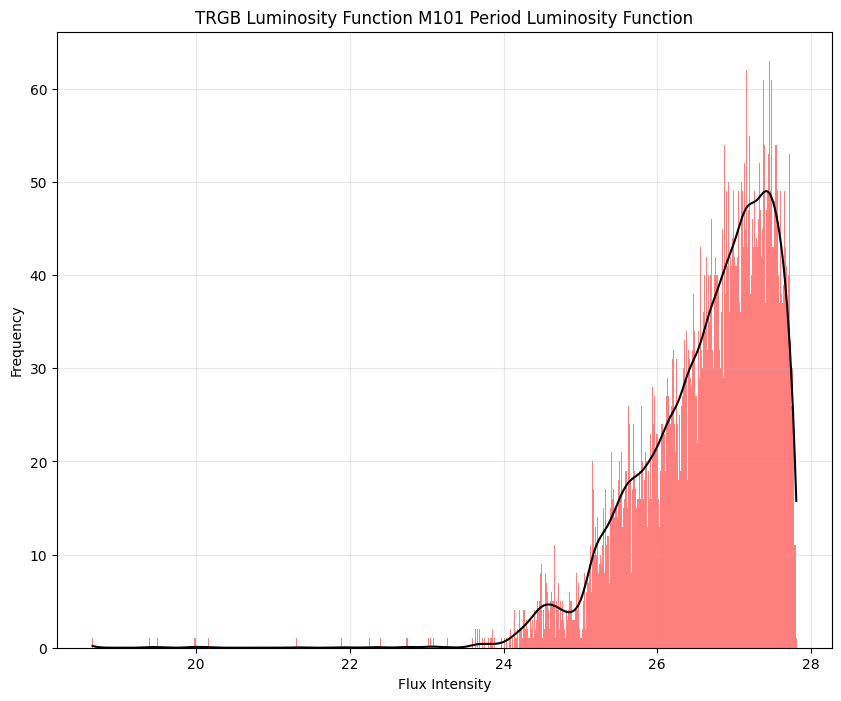

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='red', alpha=0.5)
ax.plot(X, Y, color='black')
ax.set_xlabel('Flux Intensity')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
ax.set_title('TRGB Luminosity Function M101 Period Luminosity Function')

fig.savefig('TRGB Luminosity Function M101 Period Luminosity Function')

## Task 2: Sobel Response

In [8]:
def sobel_filter(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append(hist[ii-1] * -1 + hist[ii+1])
    sobel = np.array(sobel)
    return hist[2: -2], sobel

def poisson_sobel(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append(hist[ii - 1] * -1 * 1/np.sqrt(hist[ii - 1]) + hist[ii] * 0 + hist[ii + 1] * 1* 1/np.sqrt(hist[ii + 1]))
    sobel = np.array(sobel)
    return hist[2: -2], sobel

def hatt_sobel(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append((hist[ii + 1] - hist[ii - 1]) / np.sqrt(hist[ii + 1] + hist[ii - 1]))
    sobel = np.array(sobel)
    return hist[2: -2], sobel

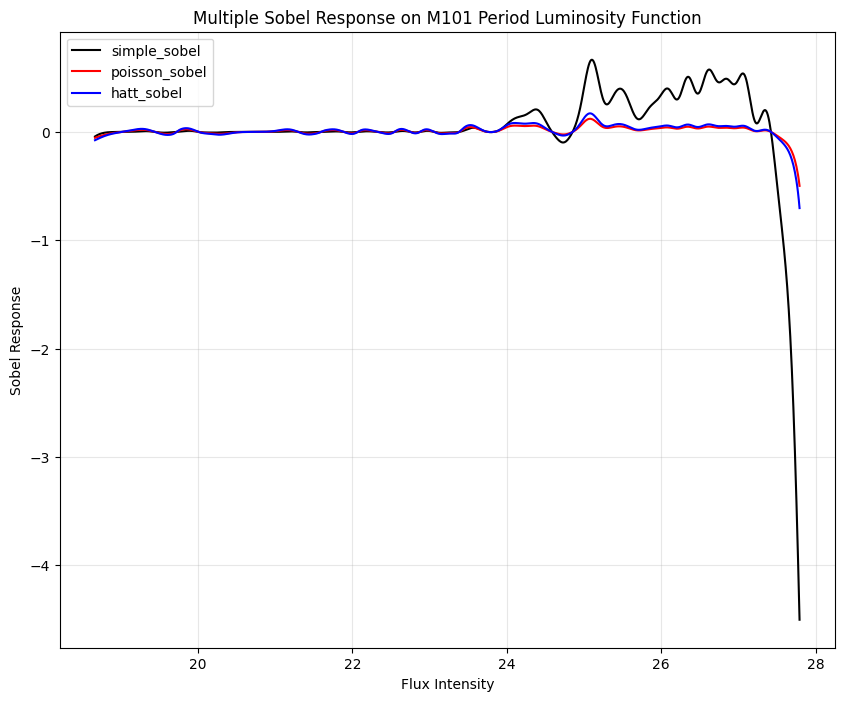

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(X[2: -2], sobel_filter(Y)[1], color='black', label='simple_sobel')
ax.plot(X[2:-2], poisson_sobel(Y)[1], color='red', label='poisson_sobel')
ax.plot(X[2:-2], hatt_sobel(Y)[1], color='blue', label='hatt_sobel')
ax.legend()

ax.set_xlabel('Flux Intensity')
ax.set_ylabel('Sobel Response')
ax.set_title('Multiple Sobel Response on M101 Period Luminosity Function')
ax.grid(True, alpha=0.3)
fig.savefig('Multiple Sobel Response on M101 Period Luminosity Function')

## Task 3: Color Magnitude Diagrams and Assembled Plots


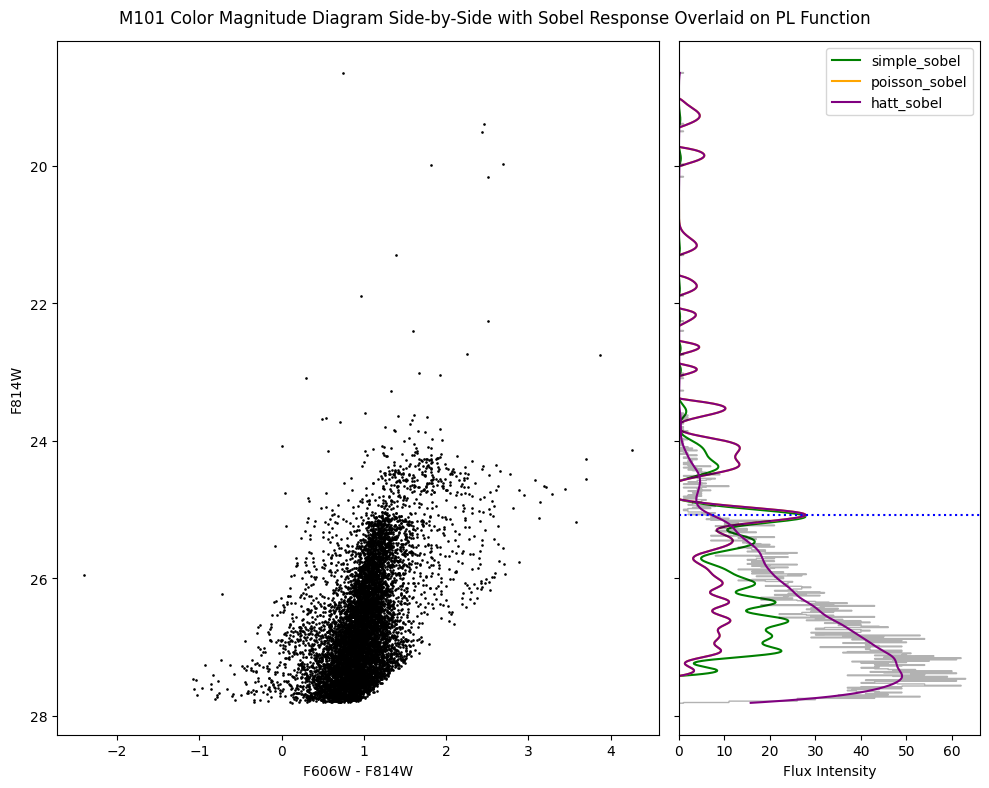

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), sharey=True, gridspec_kw={'width_ratios': [2, 1]})

# CMD
ax1.scatter(diff_data, mag_data, color='black', s=0.8)
ax1.yaxis.set_inverted(True)
ax1.set_xlabel('F606W - F814W')
ax1.set_ylabel('F814W')

# sobel response
scaling_factor_hatt = np.max(mag_data) / np.max(hatt_sobel(Y)[1]) # this is for visual scaling (hatt)
scaling_factor_simple = np.max(mag_data) / np.max(sobel_filter(Y)[1]) # this is for visual scaling (simple)
scaling_factor_poisson = np.max(mag_data) / np.max(poisson_sobel(Y)[1]) # this is for visual scaling (poisson)
ax2.plot(np.maximum(scaling_factor_simple * sobel_filter(Y)[1], 0), X[2:-2], color='green', label='simple_sobel') # hatt sobel response > 0
ax2.plot(np.maximum(scaling_factor_poisson * poisson_sobel(Y)[1], 0), X[2:-2], color='orange', label='poisson_sobel') # hatt sobel response > 0
ax2.plot(np.maximum(scaling_factor_hatt * hatt_sobel(Y)[1], 0), X[2:-2], color='purple', label='hatt_sobel') # hatt sobel response > 0
ax2.yaxis.set_inverted(True)
ax2.legend()

# histogram and gloess smoothed curve
Y, X = gloess(mag_data, 0.10)
ax2.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='black', alpha=0.3, orientation='horizontal', histtype='step', label='pl_histogram')
ax2.plot(Y, X, color='purple', label='smoothed_pl_function')

# maximum sobel response finder
max_sobel_response = np.max(hatt_sobel(Y)[1])
max_ind = np.where(hatt_sobel(Y)[1] == max_sobel_response)
max_val = (X[2: -2])[max_ind]
ax2.axhline(y=max_val, linestyle=':', color='blue')

ax2.set_xlabel('Flux Intensity')

fig.suptitle('M101 Color Magnitude Diagram Side-by-Side with Sobel Response Overlaid on PL Function')
fig.tight_layout()
fig.savefig('M101 Color Magnitude Diagram Side-by-Side with Sobel Response Overlaid on PL Function')

## Intermittent Task: 2D Persistent Homology TRGB Detector on the CMD

Rather than collapsing the CMD along color and running PH on a 1D derivative,
we detect the TRGB directly from the 2D color-magnitude diagram. Build a
Gaussian KDE `ρ(color, F814W)` on a regular grid, then run **superlevel-set
persistent homology** on `ρ` (equivalently, sublevel-set PH on `-ρ`) via
GUDHI's `CubicalComplex`. Each H0 class is born at a local density maximum and
dies when its basin merges with a denser one; persistence = `birth − death`
density.

The most persistent finite-lifetime H0 class is the dense RGB locus. Taking
its superlevel region at the death threshold `ρ*` gives the maximal region at
which the RGB exists as its own connected basin — at that threshold the bright
boundary of the region is the TRGB discontinuity. We report the TRGB as the
median over color columns of the brightest (min F814W) grid cell in that
region, giving a single horizontal tip magnitude.

In [11]:
import gudhi
from scipy.stats import gaussian_kde
from scipy.ndimage import label as cc_label


# CMD search window for M101: excludes saturation (bright end) and photometric
# completeness fall-off (faint end), and restricts to the RGB color locus.
RGB_WINDOW = (22.0, 26.0)      # F814W
COLOR_WINDOW = (1.0, 3.0)      # F606W - F814W


def ph_tip_2d(color, mag, grid=(400, 600), bandwidth=None, pad=0.05,
              mag_window=RGB_WINDOW, color_window=COLOR_WINDOW, n_threshold=400):
    """2D persistent homology TRGB detector on the CMD.

    Pipeline:
      1. Restrict stars to the RGB search box (color_window x mag_window).
      2. Build a Gaussian KDE rho(color, mag) on a padded regular grid.
      3. Run superlevel-set PH on rho (sublevel-set PH on -rho) to confirm the
         RGB is the dominant persistent H0 class and to record the full
         persistence diagram.
      4. Track the bright edge m_top(t) of the connected superlevel component
         containing the global density peak as t varies.
         The TRGB discontinuity means m_top(t) has a persistent plateau: a
         range of t over which the region's bright boundary sits at the
         discontinuity and does not advance further bright-ward until t drops
         below the (much lower) above-TRGB density.
      5. Report the plateau value as the TRGB magnitude: the t at which
         d m_top / d log(t) is closest to zero.

    Returns
    -------
    tip_mag, t_star, region, h0_pairs, c_edges, m_edges, rho
    """
    color = np.asarray(color)
    mag = np.asarray(mag)
    finite = np.isfinite(color) & np.isfinite(mag)
    color = color[finite]
    mag = mag[finite]

    m_lo, m_hi = mag_window
    c_lo, c_hi = color_window
    sel = (mag >= m_lo) & (mag <= m_hi) & (color >= c_lo) & (color <= c_hi)
    color = color[sel]
    mag = mag[sel]

    dc = (c_hi - c_lo) * pad
    dm = (m_hi - m_lo) * pad
    c_lo_g, c_hi_g = c_lo - dc, c_hi + dc
    m_lo_g, m_hi_g = m_lo - dm, m_hi + dm

    Nc, Nm = grid
    c_edges = np.linspace(c_lo_g, c_hi_g, Nc)
    m_edges = np.linspace(m_lo_g, m_hi_g, Nm)
    CC, MM = np.meshgrid(c_edges, m_edges)  # (Nm, Nc)

    kde = gaussian_kde(np.vstack([color, mag]), bw_method=bandwidth)
    rho = kde(np.vstack([CC.ravel(), MM.ravel()])).reshape(Nm, Nc)

    # Persistence diagram (diagnostic; informs which H0 class is the RGB).
    cc = gudhi.CubicalComplex(top_dimensional_cells=-rho)
    cc.persistence(homology_coeff_field=2, min_persistence=0)
    regular, _ = cc.cofaces_of_persistence_pairs()
    rho_flat = rho.ravel()
    h0_pairs = []
    if len(regular) > 0:
        for b_idx, d_idx in regular[0]:
            rho_b = rho_flat[b_idx]
            rho_d = rho_flat[d_idx]
            h0_pairs.append((rho_b, rho_d, rho_b - rho_d, int(b_idx)))
    h0_pairs.sort(key=lambda p: p[2], reverse=True)

    # Bright-edge curve of the RGB basin (superlevel component containing the global peak)
    peak = np.unravel_index(int(rho.argmax()), rho.shape)
    t_grid = np.linspace(rho.max() * 0.02, rho.max() * 0.98, n_threshold)
    m_top = np.empty_like(t_grid)
    for k, t in enumerate(t_grid):
        mask = rho >= t
        lab, _ = cc_label(mask)
        if lab[peak] == 0:
            m_top[k] = np.nan
            continue
        region_k = lab == lab[peak]
        tips = [m_edges[np.argmax(region_k[:, j])] for j in range(Nc) if region_k[:, j].any()]
        m_top[k] = float(np.median(tips)) if tips else np.nan

    # Plateau: minimum |d m_top / d log t| away from the endpoints.
    valid = np.isfinite(m_top)
    log_t = np.log(t_grid)
    d_edge = np.gradient(m_top, log_t)
    margin = max(n_threshold // 10, 5)
    interior = np.zeros_like(valid)
    interior[margin:-margin] = True
    searchable = valid & interior
    if not searchable.any():
        return np.nan, np.nan, None, h0_pairs, c_edges, m_edges, rho
    idxs = np.where(searchable)[0]
    k_star = idxs[np.argmin(np.abs(d_edge[idxs]))]
    t_star = float(t_grid[k_star])
    tip_mag = float(m_top[k_star])

    mask = rho >= t_star
    lab, _ = cc_label(mask)
    region = lab == lab[peak]

    return tip_mag, t_star, region, h0_pairs, c_edges, m_edges, rho

PH-2D tip (F814W) = 25.003
Sobel tip (F814W) = 25.080
t* (plateau threshold) = 0.3365
Top 5 H0 persistences: [np.float64(0.5662), np.float64(0.0063), np.float64(0.0063), np.float64(0.0027), np.float64(0.0)]


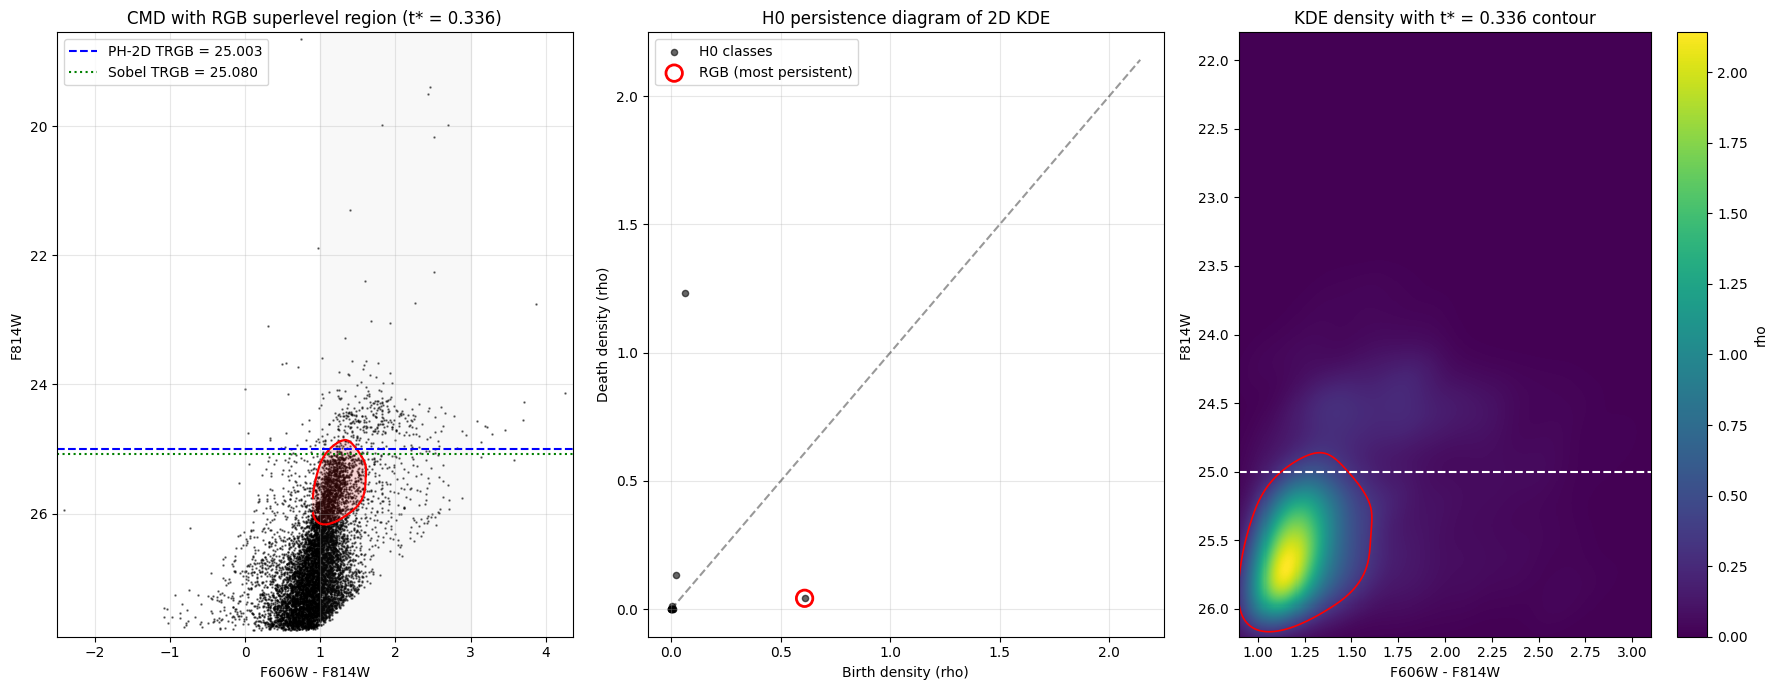

In [12]:
tip_mag, t_star, region, h0_pairs, c_edges, m_edges, rho = ph_tip_2d(diff_data, mag_data)

# Sobel reference tip (Hatt) on the 1D LF, for cross-check
Y, X = gloess(mag_data, 0.10)
hatt_resp = hatt_sobel(Y)[1]
X_hatt = X[2:-2]
hatt_mask = (X_hatt >= RGB_WINDOW[0]) & (X_hatt <= RGB_WINDOW[1])
sobel_mag = X_hatt[hatt_mask][np.argmax(hatt_resp[hatt_mask])]

print(f"PH-2D tip (F814W) = {tip_mag:.3f}")
print(f"Sobel tip (F814W) = {sobel_mag:.3f}")
print(f"t* (plateau threshold) = {t_star:.4g}")
print(f"Top 5 H0 persistences: {[round(p[2], 4) for p in h0_pairs[:5]]}")

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# (1) CMD with RGB superlevel region and TRGB line
axes[0].scatter(diff_data, mag_data, s=0.6, color='black', alpha=0.5)
axes[0].contour(c_edges, m_edges, region.astype(float), levels=[0.5], colors='red', linewidths=1.5)
axes[0].contourf(c_edges, m_edges, region.astype(float), levels=[0.5, 1.5], colors=['red'], alpha=0.15)
axes[0].axhline(tip_mag, color='blue', linestyle='--', lw=1.5, label=f'PH-2D TRGB = {tip_mag:.3f}')
axes[0].axhline(sobel_mag, color='green', linestyle=':', lw=1.5, label=f'Sobel TRGB = {sobel_mag:.3f}')
axes[0].axvspan(COLOR_WINDOW[0], COLOR_WINDOW[1], color='gray', alpha=0.05)
axes[0].set_xlim(diff_data.min() - 0.1, diff_data.max() + 0.1)
axes[0].set_ylim(mag_data.max() + 0.1, mag_data.min() - 0.1)  # inverted
axes[0].set_xlabel('F606W - F814W')
axes[0].set_ylabel('F814W')
axes[0].set_title(f'CMD with RGB superlevel region (t* = {t_star:.3g})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (2) Persistence diagram of H0 on rho
births = np.array([p[0] for p in h0_pairs])
deaths = np.array([p[1] for p in h0_pairs])
axes[1].scatter(births, deaths, s=20, color='black', alpha=0.6, label='H0 classes')
if len(h0_pairs):
    axes[1].scatter([h0_pairs[0][0]], [h0_pairs[0][1]], s=140, edgecolor='red',
                    facecolor='none', linewidth=2, label='RGB (most persistent)')
lo = 0.0
hi = float(rho.max())
axes[1].plot([lo, hi], [lo, hi], 'k--', alpha=0.4)
axes[1].set_xlabel('Birth density (rho)')
axes[1].set_ylabel('Death density (rho)')
axes[1].set_title('H0 persistence diagram of 2D KDE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# (3) KDE density map with TRGB line
im = axes[2].pcolormesh(c_edges, m_edges, rho, shading='auto', cmap='viridis')
axes[2].contour(c_edges, m_edges, rho, levels=[t_star], colors='red', linewidths=1.2)
axes[2].axhline(tip_mag, color='white', linestyle='--', lw=1.5)
axes[2].yaxis.set_inverted(True)
axes[2].set_xlabel('F606W - F814W')
axes[2].set_ylabel('F814W')
axes[2].set_title(f'KDE density with t* = {t_star:.3g} contour')
fig.colorbar(im, ax=axes[2], label='rho')

fig.tight_layout()
fig.savefig('TRGB Persistent Homology Diagnostic')

Bootstrap PH-2D tip = 25.021  (+0.033 / -0.033) over 50 samples


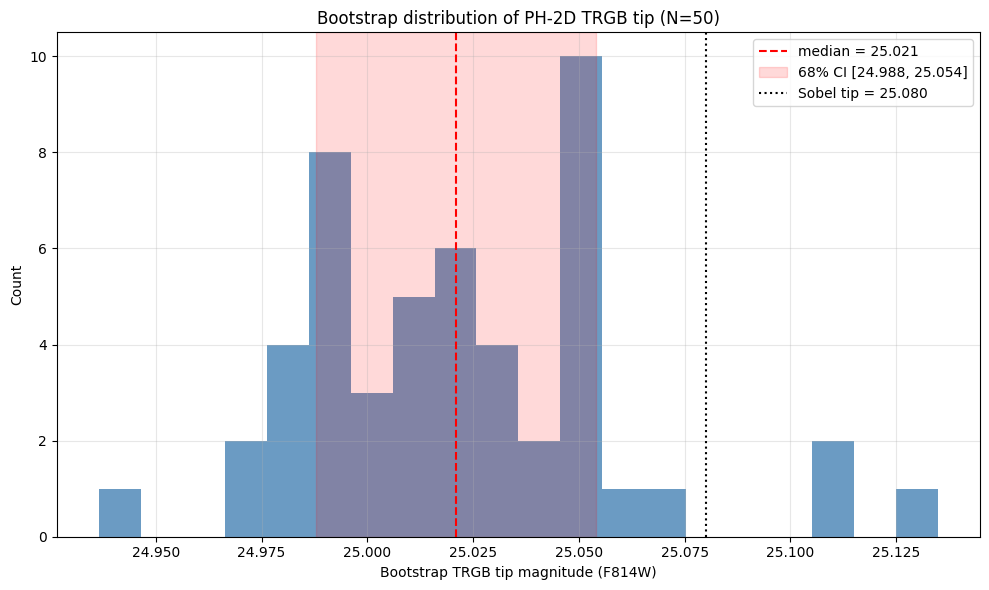

In [13]:
rng = np.random.default_rng(42)
N_BOOT = 50  # 2D PH is slower than 1D; 50 is enough for a CI estimate

mag_arr = data['inst_vega_mag2'].values
mag1_arr = data['inst_vega_mag1'].values
err1 = data['mag1_err'].values
err2 = data['mag2_err'].values
n = len(mag_arr)

boot_tips = []
for b in range(N_BOOT):
    idx = rng.integers(0, n, size=n)
    m_samp = mag_arr[idx] + rng.normal(0, err2[idx])
    c_samp = (mag1_arr[idx] + rng.normal(0, err1[idx])) - m_samp
    tip_b, *_ = ph_tip_2d(c_samp, m_samp)
    boot_tips.append(tip_b)

boot_tips = np.array(boot_tips)
boot_tips = boot_tips[np.isfinite(boot_tips)]

med = np.median(boot_tips)
lo, hi = np.percentile(boot_tips, [16, 84])
print(f"Bootstrap PH-2D tip = {med:.3f}  (+{hi-med:.3f} / -{med-lo:.3f}) over {len(boot_tips)} samples")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(boot_tips, bins=20, color='steelblue', alpha=0.8)
ax.axvline(med, color='red', linestyle='--', label=f'median = {med:.3f}')
ax.axvspan(lo, hi, color='red', alpha=0.15, label=f'68% CI [{lo:.3f}, {hi:.3f}]')
ax.axvline(sobel_mag, color='black', linestyle=':', label=f'Sobel tip = {sobel_mag:.3f}')
ax.set_xlabel('Bootstrap TRGB tip magnitude (F814W)')
ax.set_ylabel('Count')
ax.set_title(f'Bootstrap distribution of PH-2D TRGB tip (N={len(boot_tips)})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('TRGB Persistent Homology Bootstrap')

bw_factor=0.50  PH-2D=25.076
bw_factor=0.75  PH-2D=25.047
bw_factor=1.00  PH-2D=25.017
bw_factor=1.50  PH-2D=25.025
bw_factor=2.00  PH-2D=25.061


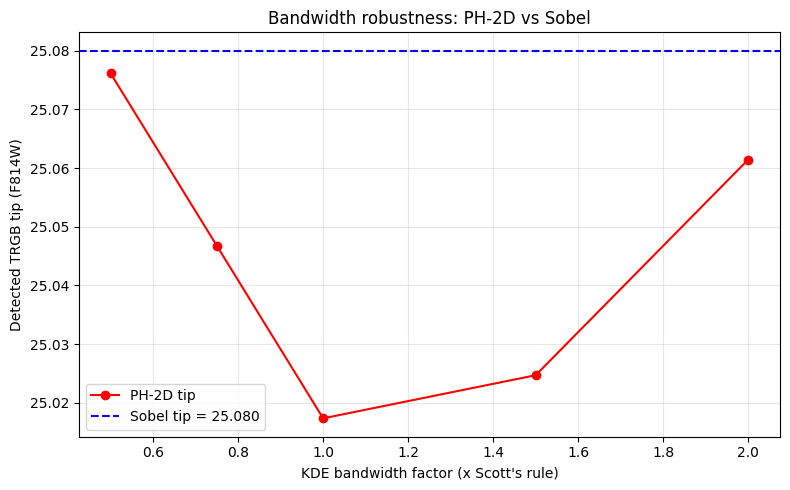

In [14]:
bw_factors = [0.5, 0.75, 1.0, 1.5, 2.0]  # scaling of Scott's-rule bandwidth
ph2d_by_bw = []
for f in bw_factors:
    tip_f, *_ = ph_tip_2d(diff_data, mag_data, bandwidth=f * gaussian_kde(
        np.vstack([diff_data, mag_data])).factor)
    ph2d_by_bw.append(tip_f)
    print(f"bw_factor={f:.2f}  PH-2D={tip_f:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bw_factors, ph2d_by_bw, 'o-', color='red', label='PH-2D tip')
ax.axhline(sobel_mag, color='blue', linestyle='--', label=f'Sobel tip = {sobel_mag:.3f}')
ax.set_xlabel("KDE bandwidth factor (x Scott's rule)")
ax.set_ylabel('Detected TRGB tip (F814W)')
ax.set_title('Bandwidth robustness: PH-2D vs Sobel')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('TRGB Persistent Homology Bandwidth Robustness')